# [실습 10-1] Keras CNN으로 CIFAR-10 분류 — 완전연결 대비 Before/After

| 항목 | 내용 |
|---|---|
| 예상 소요 시간 | 40~50분 (**GPU 권장** — Colab T4 기준 학습 셀 각 3~5분) |
| 본문 연계 | 10.2 CNN 구조 |
| 선수 실습 | [실습 9-2] (Keras 완전연결 MNIST — Before 모델의 원형) |
| 준비 | 부록 B.1·B.3 참고. 최초 실행 시 CIFAR-10 다운로드(약 170MB, 1회만) |

9장의 완전연결 신경망과 CNN을 **같은 데이터·같은 학습 설정**으로
겨루게 한다 — 바뀐 것은 구조뿐인데 결과가 달라지는 것이
"공간 구조를 보는 눈"의 효과다.

### [준비] 환경 설정 (저장소 전용)

In [1]:
# 저장소 루트를 임포트 경로에 추가
# (Colab에서는 아래 두 줄의 주석을 해제하고 실행)
# !git clone https://github.com/tbgoodlife/ai-labs.git
# %cd ai-labs
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "utils").exists():
    ROOT = ROOT.parent          # ch10/에서 연 경우
sys.path.insert(0, str(ROOT))

import platform
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
from utils import plot_style, viz

from utils.data import fix_ssl

plot_style.apply()              # 도해 스타일 킷 적용
fix_ssl()                       # 로컬 macOS 다운로드 대비
print("Python", platform.python_version())
print("TensorFlow", tf.__version__)
gpus = tf.config.list_physical_devices("GPU")
print("GPU:", gpus[0].name if gpus else
      "없음 — Colab 메뉴 [런타임 유형 변경]에서 T4 선택")

import warnings
warnings.filterwarnings("ignore")   # Keras 이행기 경고 정리
keras.utils.set_random_seed(10)     # 저장소 재현용 시드
# (지면 안내대로 학습 수치는 초기화·환경에 따라 다소 변동한다)

Python 3.12.6
TensorFlow 2.21.0
GPU: 없음 — Colab 메뉴 [런타임 유형 변경]에서 T4 선택


### [셀 1] CIFAR-10 적재 📖

학습 (50000, 32, 32, 3), 평가 (10000, 32, 32, 3)


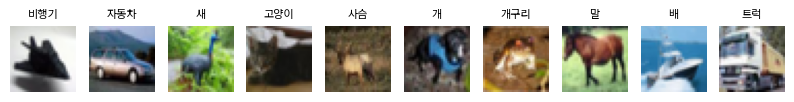

array([<Axes: title={'center': '비행기'}>, <Axes: title={'center': '자동차'}>,
       <Axes: title={'center': '새'}>, <Axes: title={'center': '고양이'}>,
       <Axes: title={'center': '사슴'}>, <Axes: title={'center': '개'}>,
       <Axes: title={'center': '개구리'}>, <Axes: title={'center': '말'}>,
       <Axes: title={'center': '배'}>, <Axes: title={'center': '트럭'}>],
      dtype=object)

In [2]:
from tensorflow import keras

(X_tr, y_tr), (X_te, y_te) = \
    keras.datasets.cifar10.load_data()
X_tr, X_te = X_tr / 255.0, X_te / 255.0
CLASSES = ["비행기", "자동차", "새", "고양이", "사슴",
           "개", "개구리", "말", "배", "트럭"]
print(f"학습 {X_tr.shape}, 평가 {X_te.shape}")
viz.show_samples(X_tr, y_tr, CLASSES, n=10)

**핵심 포인트**
- MNIST(흑백 28×28)와 달리 마지막 차원이 3 — 컬러 채널이다. 필터도 채널 방향으로 두꺼워진다.
- 표본 이미지를 보면 32×32가 얼마나 거친 해상도인지 실감된다 — 사람에게도 쉽지 않은 문제다.

### [셀 2] Before — 9장식 완전연결 모델 📖

In [3]:
from tensorflow.keras import layers

fc = keras.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(512, activation="relu"),
    layers.Dense(256, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
fc.compile(optimizer="adam",
           loss="sparse_categorical_crossentropy",
           metrics=["accuracy"])
fc.fit(X_tr, y_tr, epochs=10, batch_size=64,
       validation_split=0.1, verbose=0)
fc_acc = fc.evaluate(X_te, y_te, verbose=0)[1]
print(f"완전연결(Before) 평가 정확도: {fc_acc:.3f}")

완전연결(Before) 평가 정확도: 0.472


**핵심 포인트**
- 실습 9-2와 같은 방식의 구조다 — 데이터만 손글씨에서 컬러 사진으로 바뀌었다.
- 첫 `Dense` 층의 파라미터만 (3,072 + 1) × 512 = 1,573,376개(편향 포함), 모델 전체로는 1,707,274개다 — 앞서 예고한 다이얼 폭발의 실물이다.

### [셀 3] After — CNN 모델 📖

In [4]:
cnn = keras.Sequential([
    layers.Conv2D(32, (3, 3), padding="same",
                  activation="relu",
                  input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), padding="same",
                  activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"),
])
cnn.compile(optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"])
cnn.summary()   # 첫 합성곱층 파라미터 896개 확인

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545,098 (2.08 MB)

 Trainable params: 545,098 (2.08 MB)

 Non-trainable params: 0 (0.00 B)

**핵심 포인트**
- `Conv2D(32, (3, 3))`이 "3×3 필터 32개", `padding="same"`이 크기 유지 패딩, `MaxPooling2D((2, 2))`가 절반 요약이다. 앞서 본 합성곱·풀링 부품의 조립이다.
- `summary()`에서 첫 합성곱층 파라미터가 **896**으로, 본문 손계산 (3×3×3 + 1) × 32와 정확히 일치한다(편향 포함 관례).
- 구조는 "합성곱-풀링 두 번 → 분류층", CNN의 가장 기본형이다.

### [셀 4] 대결 결과 📖

In [5]:
cnn.fit(X_tr, y_tr, epochs=10, batch_size=64,
        validation_split=0.1, verbose=0)
cnn_acc = cnn.evaluate(X_te, y_te, verbose=0)[1]
print(f"완전연결(Before): {fc_acc:.3f}")
print(f"CNN(After):      {cnn_acc:.3f}")

완전연결(Before): 0.472
CNN(After):      0.676


**핵심 포인트**
- 같은 에폭·같은 옵티마이저에서 정확도 차이가 20%포인트 가까이 벌어진다. 공간 구조를 보는 눈의 효과다.
- 심지어 전체 파라미터는 CNN이 545,098개로 완전연결(1,707,274개)의 3분의 1이다. 가중치 공유의 효과가 모델 단위로 확인된다. 저장소 [보조 1]의 곡선 비교, [보조 2]의 학습된 필터·특징 맵 시각화까지 확인해 보자.

### [보조 1] 학습 곡선 겹쳐 보기

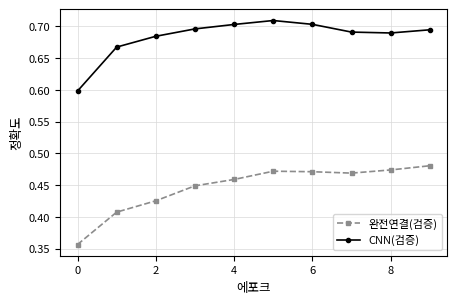

In [6]:
fig, ax = plt.subplots(figsize=(5, 3.2))
ax.plot(fc.history.history["val_accuracy"], "--",
        color="#8c8c8c", lw=1.2, marker="s", ms=3,
        label="완전연결(검증)")
ax.plot(cnn.history.history["val_accuracy"], "-",
        color="black", lw=1.2, marker="o", ms=3,
        label="CNN(검증)")
ax.set_xlabel("에포크")
ax.set_ylabel("정확도")
ax.legend()
plt.show()

### [보조 2] CNN은 무엇을 보고 있는가 — 특징 맵 엿보기

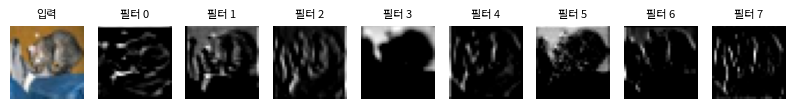

In [7]:
# 첫 합성곱 층의 출력(특징 맵) 8장을 시각화한다
probe = keras.Model(cnn.inputs,
                    cnn.layers[0].output)
fmap = probe.predict(X_te[:1], verbose=0)[0]

fig, axes = plt.subplots(1, 9, figsize=(10, 1.4))
axes[0].imshow(X_te[0])
axes[0].set_title("입력", fontsize=8)
for i, ax in enumerate(axes[1:]):
    ax.imshow(fmap[:, :, i], cmap="gray")
    ax.set_title(f"필터 {i}", fontsize=8)
for ax in axes:
    ax.axis("off")
plt.show()
# 어떤 필터는 윤곽선에, 어떤 필터는 색 덩어리에
# 반응한다 — 심화 박스 "CNN은 무엇을 보고 있는가" 연동

### [심화 1] 구조 변형 실험 (연습문제 심화 연계)

In [8]:
# TODO: 아래 손잡이를 하나씩 바꿔 [셀 4] 비교표를
#       갱신하고, 효과를 과적합 관점(6장)으로 해석하자.
# 1) Conv-Pool 스택을 3개로 늘리기
# 2) 필터 수 32→64→128로 두 배씩
# 3) Dropout 0.5 제거 시 훈련/검증 곡선 간격 관찰
def build_variant(stacks=2, base=32, dropout=0.5):
    layers = [keras.layers.Input((32, 32, 3))]
    for i in range(stacks):
        layers += [
            keras.layers.Conv2D(base * 2**i, 3,
                padding="same", activation="relu"),
            keras.layers.MaxPooling2D()]
    layers += [keras.layers.Flatten(),
               keras.layers.Dense(128,
                   activation="relu")]
    if dropout:
        layers.append(keras.layers.Dropout(dropout))
    layers.append(keras.layers.Dense(10,
        activation="softmax"))
    return keras.Sequential(layers)

print(build_variant(3, 32).count_params())

356810


---
## 마무리

- 완전연결의 한계는 공간 구조의 소실과 파라미터 폭발 — CNN은 **국소 연결·가중치 공유**로 둘 다 해결한다.
- Conv(감지)-Pool(요약) 스택이 특징의 계층을 만든다 — [보조 2]에서 첫 층이 실제로 보는 것을 확인했다.
- 같은 데이터·같은 설정에서 구조만으로 정확도가 갈렸다 — "구조가 곧 사전 지식"이라는 딥러닝 설계 철학의 첫 체험.

**연습문제 연계**: [응용] 합성곱 출력 크기·파라미터 수 계산은 [셀 3] `summary()`로 자가 검증, [심화] 구조 변형은 [심화 1]에서 수행한다.

**다음 실습**: [실습 10-2] 전이학습 (`lab-10-02_transfer-learning.ipynb`)